In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df.shape

(1338, 7)

In [6]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

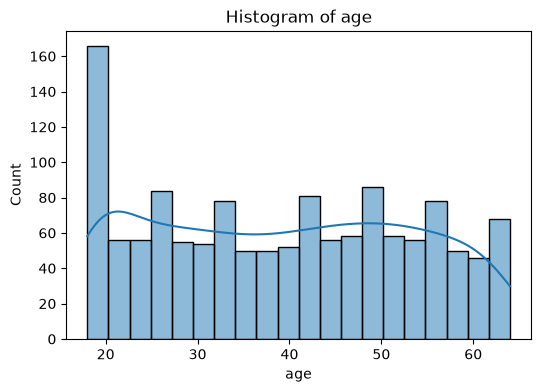

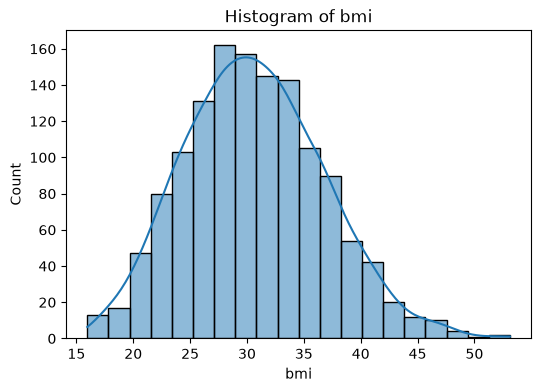

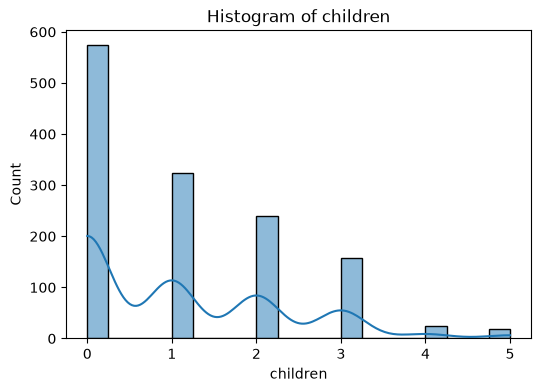

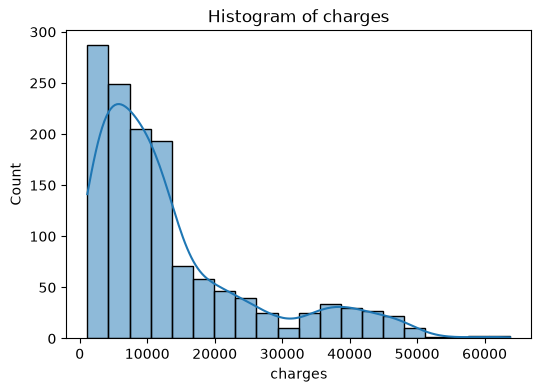

In [9]:
numeric_columns = ['age', 'bmi', 'children', 'charges']

for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

<Axes: xlabel='sex', ylabel='count'>

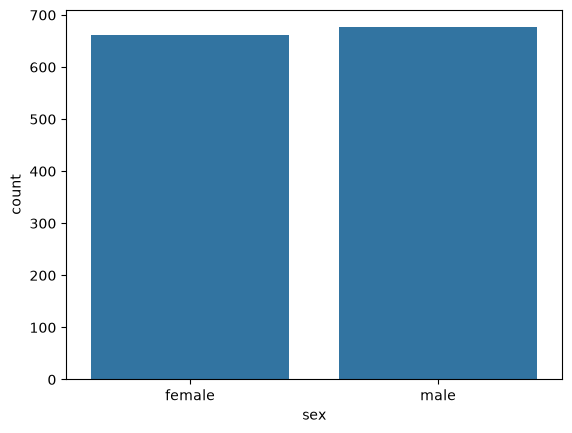

In [10]:
sns.countplot(x= df.sex)

<Axes: xlabel='smoker', ylabel='count'>

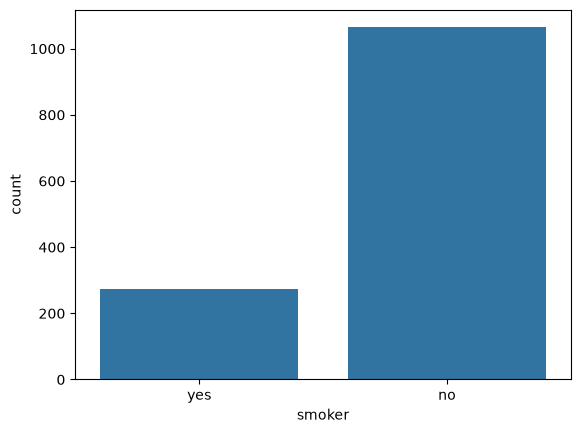

In [11]:
sns.countplot(x = df.smoker)

<Axes: xlabel='region', ylabel='count'>

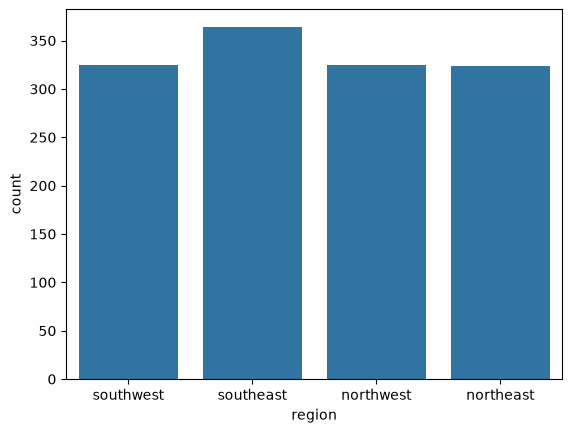

In [12]:
sns.countplot(x = df.region)

OUTLIERS

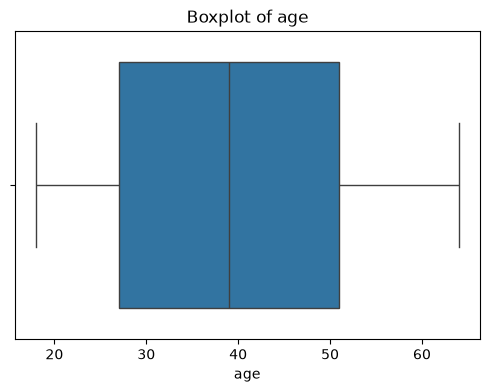

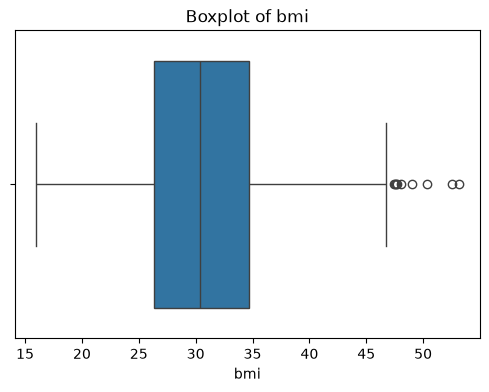

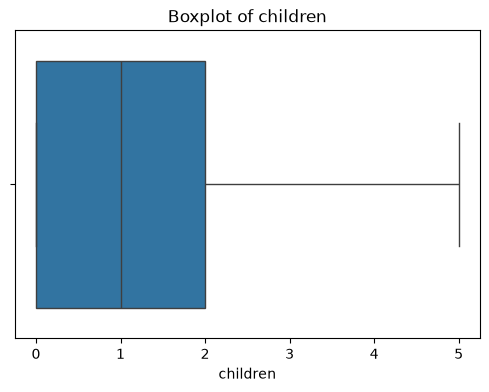

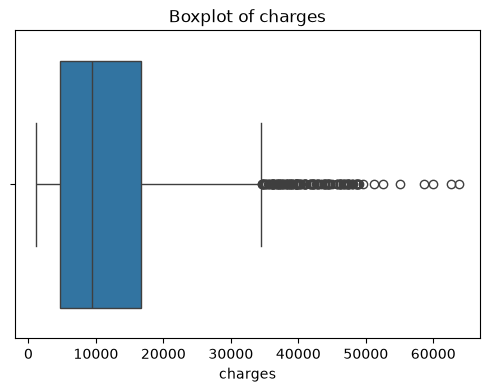

In [13]:
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()  

CORRELATION

<Axes: >

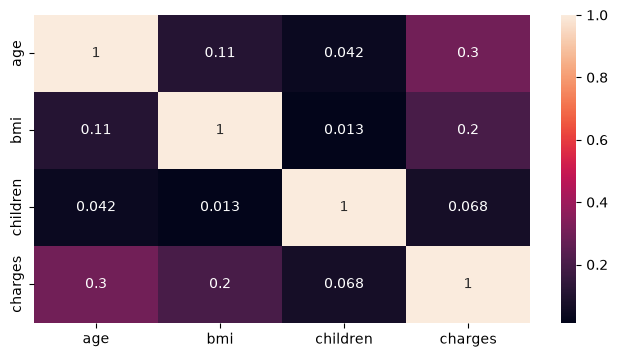

In [14]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)

DATA CLEANING & PREPROCCESSING

In [15]:
df_clean= df.copy()

In [16]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
df_clean.shape

(1338, 7)

In [18]:
df_clean.drop_duplicates(inplace=True)

In [19]:
df_clean.shape

(1337, 7)

In [20]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [21]:
df_clean.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [22]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

LABEL ENCODING(0s & 1s)

In [23]:
df_clean['sex'] = df_clean['sex'].map({'male': 0, 'female': 1})

In [24]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [25]:
df_clean['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [26]:
df_clean['smoker'] = df_clean['smoker'].map({'no': 0, 'yes': 1})

In [27]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [28]:
df_clean.rename(columns={
    'sex': 'Is_Female',
    'smoker': 'Is_Smoker'
}, inplace=True)

In [29]:
df_clean

,age,Is_Female,bmi,children,Is_Smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


ONE HOT ENCODING  (More than 2 catagories)

In [30]:
df_clean['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [31]:
df_clean = pd.get_dummies(df_clean, columns = ['region'])

In [32]:
df_clean.head()

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [33]:
df_clean = df_clean.astype(int)
df_clean

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


FEATURE ENGINEERING

<Axes: xlabel='bmi', ylabel='Count'>

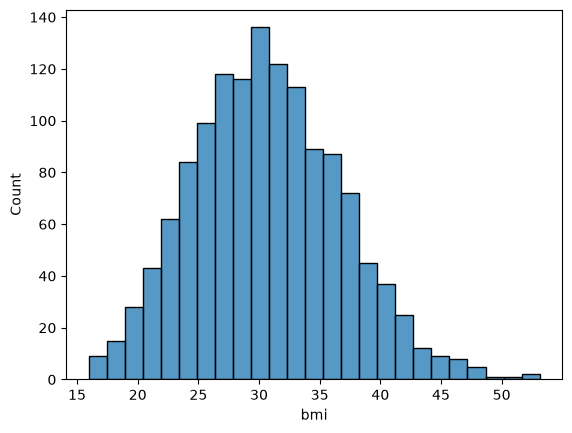

In [34]:
sns.histplot(df['bmi'])

In [35]:
df_clean['BMI_Category'] = pd.cut(
    df_clean['bmi'],
    bins=[0, 18.5, 24.9,29.9, np.inf],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

df_clean.head()

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,BMI_Category
0,19,1,27,0,1,16884,0,0,0,1,Overweight
1,18,0,33,1,0,1725,0,0,1,0,Obese
2,28,0,33,3,0,4449,0,0,1,0,Obese
3,33,0,22,0,0,21984,0,1,0,0,Normal
4,32,0,28,0,0,3866,0,1,0,0,Overweight


In [36]:
df_clean = pd.get_dummies(df_clean, columns=['BMI_Category'])

In [37]:
df_clean

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,BMI_Category_Underweight,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese
0,19,1,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,False,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,False,False,False,True
1334,18,1,31,0,0,2205,1,0,0,0,False,False,False,True
1335,18,1,36,0,0,1629,0,0,1,0,False,False,False,True
1336,21,1,25,0,0,2007,0,0,0,1,False,False,True,False


In [38]:
df_clean = df_clean.astype(int)


In [39]:
df_clean.head()

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,BMI_Category_Underweight,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


FEATURE SCALING

In [40]:
df_clean.columns

Index(['age', 'Is_Female', 'bmi', 'children', 'Is_Smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'BMI_Category_Underweight', 'BMI_Category_Normal',
       'BMI_Category_Overweight', 'BMI_Category_Obese'],
      dtype='str')

In [41]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

df_clean[cols] = scaler.fit_transform(df_clean[cols])

In [42]:
df_clean

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,BMI_Category_Underweight,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1,0,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,1,0,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,0,1,0,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,0,1,0,0,1,0


FEATURE EXTRACTION

In [43]:
selected_feature = [
    'age', 'Is_Female', 'bmi', 'children', 'Is_Smoker', 'charges',
    'region_northwest', 'region_southeast', 'region_southwest',
    'BMI_Category_Normal', 'BMI_Category_Overweight', 'BMI_Category_Obese'
]

data = []

for feature in selected_feature:
    corr = df_clean[feature].corr(df_clean['charges'])
    data.append([feature, corr])

corr_df = pd.DataFrame(data, columns=['Feature', 'Correlation'])

corr_df

,Feature,Correlation
0,age,0.298309
1,Is_Female,-0.058046
2,bmi,0.196236
3,children,0.067390
4,Is_Smoker,0.787234
5,charges,1.000000
6,region_northwest,-0.038695
7,region_southeast,0.073577
8,region_southwest,-0.043637
9,BMI_Category_Normal,-0.104042


In [44]:
corr_df['Decision'] = np.where(abs(corr_df['Correlation']) < 0.05, 'Drop Feature', 'Accept Feature')

corr_df

,Feature,Correlation,Decision
0,age,0.298309,Accept Feature
1,Is_Female,-0.058046,Accept Feature
2,bmi,0.196236,Accept Feature
3,children,0.067390,Accept Feature
4,Is_Smoker,0.787234,Accept Feature
5,charges,1.000000,Accept Feature
6,region_northwest,-0.038695,Drop Feature
7,region_southeast,0.073577,Accept Feature
8,region_southwest,-0.043637,Drop Feature
9,BMI_Category_Normal,-0.104042,Accept Feature


In [45]:
final_df = df_clean[
    ['age', 'Is_Female', 'bmi', 'children', 'Is_Smoker', 'charges', 'region_southeast', 'BMI_Category_Normal', 'BMI_Category_Overweight', 'BMI_Category_Obese']
                    ]

In [46]:
final_df

,age,Is_Female,bmi,children,Is_Smoker,charges,region_southeast,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0


MODEL TRAINING

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
x = final_df.drop('charges', axis=1)
y = final_df['charges']


In [49]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[3480.74, 68.52, 480.03,..., 557.77, 738.94,4072.77]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['age','Is_Female','bmi',...,'BMI_Category_Normal', 'BMI_Category_Overweight','BMI_Category_Obese']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6044
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [52]:
y_pred = model.predict(x_test)

In [53]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

r2

0.803387635961308

In [54]:
n = x_test.shape[0]
p = x_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
adjusted_r2

0.796529065122749